# 02: CV Feature Analysis 

The design goals are:

- **Class 2 — cropped:** measure whether actual foreground components or edge structure terminate at the image boundary, rather than relying mainly on a single global page bounding box.
- **Class 3 — degraded:** detect blur, low contrast, illumination problems, noise and threshold artefacts without allowing one healthy feature to cancel one severe defect.
- **Class 4 — non-document:** preserve the existing background, saturation and histogram features that already worked reasonably well.

The final table is saved as `cv_features_v3.csv`. Notebook 3 should fit its scaler on the tuning split and rebuild the three scores from these raw features.

## 1. Imports and dataset paths

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATASET_ROOT = Path("../eval/dataset")
MANIFEST_PATH = DATASET_ROOT / "manifest.json"

V3_FEATURE_PATH = DATASET_ROOT / "cv_features_v3.csv"

NORMALIZED_SHORT_SIDE = 800
RANDOM_SEED = 42

print("Dataset root:", DATASET_ROOT.resolve())
print("Manifest:", MANIFEST_PATH.resolve())
print("Output:", V3_FEATURE_PATH.resolve())

Dataset root: /Users/aparna/Desktop/Projects/varaha/document_gateway/eval/dataset
Manifest: /Users/aparna/Desktop/Projects/varaha/document_gateway/eval/dataset/manifest.json
Output: /Users/aparna/Desktop/Projects/varaha/document_gateway/eval/dataset/cv_features_v3.csv


## 2. Load the manifest

In [2]:
with MANIFEST_PATH.open("r", encoding="utf-8") as file:
    manifest = json.load(file)

records = manifest["images"] if isinstance(manifest, dict) else manifest
metadata_df = pd.DataFrame(records)

required_columns = {
    "image_path",
    "class_id",
    "class_name",
}

missing = required_columns - set(metadata_df.columns)

if missing:
    raise ValueError(
        f"Manifest is missing required columns: {sorted(missing)}"
    )

print("Images:", len(metadata_df))
display(
    metadata_df["class_name"]
    .value_counts()
    .rename_axis("class_name")
    .reset_index(name="count")
)

Images: 417


,class_name,count
0,clear_readable,127
1,content_cropped,127
2,unclear_degraded,127
3,non_document,36


## 3. Shared image utilities

All images are resized to the same short side before feature extraction. This keeps pixel-scale features reasonably comparable while preserving aspect ratio.

In [3]:
def read_image(image_path: Path) -> np.ndarray:
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    return image


def resize_preserving_aspect_ratio(
    image: np.ndarray,
    short_side: int = NORMALIZED_SHORT_SIDE,
) -> np.ndarray:
    height, width = image.shape[:2]
    current_short_side = min(height, width)

    if current_short_side == short_side:
        return image

    scale = short_side / current_short_side
    new_width = max(1, int(round(width * scale)))
    new_height = max(1, int(round(height * scale)))

    interpolation = (
        cv2.INTER_AREA
        if scale < 1
        else cv2.INTER_LINEAR
    )

    return cv2.resize(
        image,
        (new_width, new_height),
        interpolation=interpolation,
    )


def safe_divide(
    numerator: float,
    denominator: float,
    default: float = 0.0,
) -> float:
    if abs(denominator) < 1e-12:
        return default

    return float(numerator / denominator)


def safe_minmax(
    series: pd.Series,
    lower_quantile: float = 0.02,
    upper_quantile: float = 0.98,
) -> pd.Series:
    lower = float(series.quantile(lower_quantile))
    upper = float(series.quantile(upper_quantile))

    if upper <= lower:
        return pd.Series(
            np.zeros(len(series)),
            index=series.index,
        )

    clipped = series.clip(lower, upper)
    return (clipped - lower) / (upper - lower)

## 4. Baseline document and document-likeness features

In [4]:
def estimate_document_bbox(
    image: np.ndarray,
) -> tuple[int, int, int, int, bool]:
    height, width = image.shape[:2]
    image_area = height * width

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edge_map = cv2.Canny(blurred, 40, 130)

    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (15, 15),
    )

    connected = cv2.morphologyEx(
        edge_map,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2,
    )

    contours, _ = cv2.findContours(
        connected,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    candidates = []

    for contour in contours:
        contour_area = cv2.contourArea(contour)
        x, y, box_width, box_height = cv2.boundingRect(contour)
        box_area = box_width * box_height

        if box_area < 0.05 * image_area:
            continue

        rectangularity = safe_divide(
            contour_area,
            box_area,
        )

        score = (
            box_area / image_area
            + 0.15 * rectangularity
        )

        candidates.append(
            (score, x, y, box_width, box_height)
        )

    if not candidates:
        return 0, 0, width, height, False

    _, x, y, box_width, box_height = max(
        candidates,
        key=lambda item: item[0],
    )

    return x, y, box_width, box_height, True


def intensity_entropy(gray: np.ndarray) -> float:
    histogram = cv2.calcHist(
        [gray],
        [0],
        None,
        [256],
        [0, 256],
    ).ravel()

    total = histogram.sum()

    if total <= 0:
        return 0.0

    probabilities = histogram / total
    probabilities = probabilities[probabilities > 0]

    return float(
        -np.sum(
            probabilities
            * np.log2(probabilities)
        )
    )


def otsu_separation(gray: np.ndarray) -> float:
    histogram = cv2.calcHist(
        [gray],
        [0],
        None,
        [256],
        [0, 256],
    ).ravel()

    total = histogram.sum()

    if total <= 0:
        return 0.0

    probabilities = histogram / total
    levels = np.arange(256)

    total_mean = np.sum(levels * probabilities)
    cumulative_probability = np.cumsum(probabilities)
    cumulative_mean = np.cumsum(levels * probabilities)

    denominator = (
        cumulative_probability
        * (1.0 - cumulative_probability)
    )

    numerator = (
        total_mean * cumulative_probability
        - cumulative_mean
    ) ** 2

    valid = denominator > 0

    if not np.any(valid):
        return 0.0

    between_class_variance = np.zeros_like(
        numerator,
        dtype=np.float64,
    )

    between_class_variance[valid] = (
        numerator[valid] / denominator[valid]
    )

    total_variance = np.var(gray.astype(np.float64))

    if total_variance <= 0:
        return 0.0

    return float(
        np.max(between_class_variance)
        / total_variance
    )

## 5. Advanced crop features

In [5]:
def adaptive_foreground_mask(
    gray: np.ndarray,
) -> np.ndarray:
    # Local thresholding is more robust than a single global threshold for
    # documents with shadows or uneven illumination.
    foreground = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31,
        11,
    )

    # Remove isolated single-pixel noise without joining neighbouring text.
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (2, 2),
    )

    foreground = cv2.morphologyEx(
        foreground,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1,
    )

    return foreground


def connected_component_boundary_features(
    foreground: np.ndarray,
    boundary_fraction: float = 0.0125,
) -> dict[str, float]:
    height, width = foreground.shape
    image_area = height * width

    boundary_y = max(2, int(round(height * boundary_fraction)))
    boundary_x = max(2, int(round(width * boundary_fraction)))

    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(
        foreground,
        connectivity=8,
    )

    valid_components = 0
    touching_components = 0
    touching_area = 0
    total_component_area = 0
    sides_touched: set[str] = set()

    minimum_area = max(12, int(round(image_area * 0.00001)))
    maximum_area = int(round(image_area * 0.20))

    for component_index in range(1, num_labels):
        x, y, box_width, box_height, area = stats[component_index]

        if area < minimum_area or area > maximum_area:
            continue

        # Reject very large solid blocks that are unlikely to be characters,
        # text lines, signatures or table fragments.
        fill_ratio = safe_divide(
            area,
            box_width * box_height,
        )

        if fill_ratio > 0.95 and area > image_area * 0.005:
            continue

        valid_components += 1
        total_component_area += int(area)

        touched = False

        if x <= boundary_x:
            sides_touched.add("left")
            touched = True

        if y <= boundary_y:
            sides_touched.add("top")
            touched = True

        if x + box_width >= width - boundary_x:
            sides_touched.add("right")
            touched = True

        if y + box_height >= height - boundary_y:
            sides_touched.add("bottom")
            touched = True

        if touched:
            touching_components += 1
            touching_area += int(area)

    return {
        "crop_cc_valid_count": float(valid_components),
        "crop_cc_touch_count": float(touching_components),
        "crop_cc_touch_ratio": safe_divide(
            touching_components,
            valid_components,
        ),
        "crop_cc_touch_area_ratio": safe_divide(
            touching_area,
            total_component_area,
        ),
        "crop_cc_sides_touched": float(len(sides_touched)),
    }


def boundary_ink_features(
    foreground: np.ndarray,
    boundary_fraction: float = 0.025,
) -> dict[str, float]:
    height, width = foreground.shape

    strip_y = max(3, int(round(height * boundary_fraction)))
    strip_x = max(3, int(round(width * boundary_fraction)))

    ink = foreground > 0

    side_ratios = {
        "top": float(np.mean(ink[:strip_y, :])),
        "bottom": float(np.mean(ink[-strip_y:, :])),
        "left": float(np.mean(ink[:, :strip_x])),
        "right": float(np.mean(ink[:, -strip_x:])),
    }

    side_values = np.array(
        list(side_ratios.values()),
        dtype=np.float64,
    )

    return {
        **{
            f"crop_boundary_ink_{side}": value
            for side, value in side_ratios.items()
        },
        "crop_boundary_ink_max": float(side_values.max()),
        "crop_boundary_ink_mean": float(side_values.mean()),
        "crop_boundary_ink_sides_active": float(
            np.sum(side_values >= 0.03)
        ),
    }


def projection_boundary_features(
    foreground: np.ndarray,
    strip_fraction: float = 0.025,
) -> dict[str, float]:
    height, width = foreground.shape

    strip_y = max(3, int(round(height * strip_fraction)))
    strip_x = max(3, int(round(width * strip_fraction)))

    ink = (foreground > 0).astype(np.float32)

    row_profile = ink.mean(axis=1)
    col_profile = ink.mean(axis=0)

    top_boundary = float(row_profile[:strip_y].mean())
    bottom_boundary = float(row_profile[-strip_y:].mean())
    left_boundary = float(col_profile[:strip_x].mean())
    right_boundary = float(col_profile[-strip_x:].mean())

    top_inner = float(
        row_profile[strip_y:2 * strip_y].mean()
    )
    bottom_inner = float(
        row_profile[-2 * strip_y:-strip_y].mean()
    )
    left_inner = float(
        col_profile[strip_x:2 * strip_x].mean()
    )
    right_inner = float(
        col_profile[-2 * strip_x:-strip_x].mean()
    )

    deltas = np.array([
        max(0.0, top_boundary - top_inner),
        max(0.0, bottom_boundary - bottom_inner),
        max(0.0, left_boundary - left_inner),
        max(0.0, right_boundary - right_inner),
    ])

    ratios = np.array([
        safe_divide(top_boundary, top_inner + 1e-4),
        safe_divide(bottom_boundary, bottom_inner + 1e-4),
        safe_divide(left_boundary, left_inner + 1e-4),
        safe_divide(right_boundary, right_inner + 1e-4),
    ])

    return {
        "crop_projection_delta_max": float(deltas.max()),
        "crop_projection_delta_mean": float(deltas.mean()),
        "crop_projection_ratio_max": float(
            np.clip(ratios.max(), 0.0, 20.0)
        ),
        "crop_projection_ratio_mean": float(
            np.clip(ratios.mean(), 0.0, 20.0)
        ),
    }

## 6. Advanced quality features

The previous score averaged several “higher is better” measurements. That can hide a severe defect when other measurements remain normal. This notebook extracts separate defect signals and later combines them as a **risk score**.

Important design choices:

- FFT uses power rather than raw magnitude.
- The frequency cutoff is relative to tile size.
- Local tile percentiles reduce the influence of blank margins.
- Noise is estimated from high-pass residual energy, but is interpreted together with sharpness because true detail can also create high-frequency energy.

In [6]:
def tenengrad_mean(gray: np.ndarray) -> float:
    sobel_x = cv2.Sobel(
        gray,
        cv2.CV_64F,
        1,
        0,
        ksize=3,
    )

    sobel_y = cv2.Sobel(
        gray,
        cv2.CV_64F,
        0,
        1,
        ksize=3,
    )

    gradient_squared = (
        sobel_x ** 2
        + sobel_y ** 2
    )

    return float(np.mean(gradient_squared))


def local_laplacian_percentiles(
    gray: np.ndarray,
    grid_rows: int = 4,
    grid_cols: int = 4,
) -> dict[str, float]:
    height, width = gray.shape
    values = []

    for row_index in range(grid_rows):
        for col_index in range(grid_cols):
            y1 = int(row_index * height / grid_rows)
            y2 = int((row_index + 1) * height / grid_rows)
            x1 = int(col_index * width / grid_cols)
            x2 = int((col_index + 1) * width / grid_cols)

            tile = gray[y1:y2, x1:x2]

            if tile.size == 0 or tile.std() < 3:
                continue

            values.append(
                float(
                    cv2.Laplacian(
                        tile,
                        cv2.CV_64F,
                    ).var()
                )
            )

    if not values:
        return {
            "local_laplacian_p10": 0.0,
            "local_laplacian_p25": 0.0,
            "local_laplacian_median": 0.0,
        }

    values_array = np.asarray(values)

    return {
        "local_laplacian_p10": float(
            np.percentile(values_array, 10)
        ),
        "local_laplacian_p25": float(
            np.percentile(values_array, 25)
        ),
        "local_laplacian_median": float(
            np.median(values_array)
        ),
    }


def fft_high_frequency_ratio(
    gray: np.ndarray,
    cutoff_fraction: float = 0.12,
) -> float:
    gray_float = gray.astype(np.float32)
    gray_float = gray_float - gray_float.mean()

    spectrum = np.fft.fftshift(
        np.fft.fft2(gray_float)
    )

    power = np.abs(spectrum) ** 2

    height, width = gray.shape
    center_y = height // 2
    center_x = width // 2

    y_grid, x_grid = np.ogrid[:height, :width]
    radius = np.sqrt(
        (y_grid - center_y) ** 2
        + (x_grid - center_x) ** 2
    )

    cutoff = cutoff_fraction * min(height, width)
    high_frequency_mask = radius >= cutoff

    return safe_divide(
        float(power[high_frequency_mask].sum()),
        float(power.sum()),
    )


def local_fft_percentiles(
    gray: np.ndarray,
    grid_rows: int = 3,
    grid_cols: int = 3,
) -> dict[str, float]:
    height, width = gray.shape
    ratios = []

    for row_index in range(grid_rows):
        for col_index in range(grid_cols):
            y1 = int(row_index * height / grid_rows)
            y2 = int((row_index + 1) * height / grid_rows)
            x1 = int(col_index * width / grid_cols)
            x2 = int((col_index + 1) * width / grid_cols)

            tile = gray[y1:y2, x1:x2]

            # Exclude near-blank tiles. Blank paper should not be treated as blur.
            if tile.size == 0 or tile.std() < 5:
                continue

            ratios.append(
                fft_high_frequency_ratio(tile)
            )

    if not ratios:
        return {
            "quality_fft_global_ratio": fft_high_frequency_ratio(gray),
            "quality_fft_local_p10": 0.0,
            "quality_fft_local_p25": 0.0,
            "quality_fft_local_median": 0.0,
        }

    ratio_array = np.asarray(ratios)

    return {
        "quality_fft_global_ratio": fft_high_frequency_ratio(gray),
        "quality_fft_local_p10": float(
            np.percentile(ratio_array, 10)
        ),
        "quality_fft_local_p25": float(
            np.percentile(ratio_array, 25)
        ),
        "quality_fft_local_median": float(
            np.median(ratio_array)
        ),
    }


def illumination_features(
    gray: np.ndarray,
) -> dict[str, float]:
    mean_intensity = float(gray.mean())
    p05 = float(np.percentile(gray, 5))
    p95 = float(np.percentile(gray, 95))

    return {
        "mean_intensity": mean_intensity,
        "intensity_p05": p05,
        "intensity_p95": p95,
        "underexposed_ratio": float(np.mean(gray <= 45)),
        "overexposed_ratio": float(np.mean(gray >= 245)),
        "intensity_dynamic_range": p95 - p05,
    }


def noise_residual_mad(gray: np.ndarray) -> float:
    gray_float = gray.astype(np.float32)
    smoothed = cv2.GaussianBlur(
        gray_float,
        (0, 0),
        sigmaX=1.0,
    )

    residual = gray_float - smoothed
    median = np.median(residual)

    return float(
        np.median(np.abs(residual - median))
    )


def threshold_artifact_features(
    gray: np.ndarray,
) -> dict[str, float]:
    # Extremely bimodal scans and large black/white regions can indicate
    # aggressive adaptive thresholding or photocopy artefacts.
    near_binary_ratio = float(
        np.mean(
            (gray <= 20)
            | (gray >= 235)
        )
    )

    midtone_ratio = float(
        np.mean(
            (gray >= 60)
            & (gray <= 195)
        )
    )

    return {
        "near_binary_ratio": near_binary_ratio,
        "midtone_ratio": midtone_ratio,
    }

## 7. Extract the complete Iteration 3 feature vector

In [7]:
def extract_v3_features(
    image_path: Path,
) -> dict[str, Any]:
    image = resize_preserving_aspect_ratio(
        read_image(image_path)
    )

    height, width = image.shape[:2]

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY,
    )

    hsv = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2HSV,
    )

    edge_map = cv2.Canny(
        gray,
        50,
        150,
    )

    foreground = adaptive_foreground_mask(gray)

    # ---------------------------------------------------------
    # Baseline page geometry
    # ---------------------------------------------------------
    x, y, box_width, box_height, bbox_found = (
        estimate_document_bbox(image)
    )

    margin_ratios = [
        x / width,
        (width - (x + box_width)) / width,
        y / height,
        (height - (y + box_height)) / height,
    ]

    edge_touch_count = sum(
        margin <= 0.01
        for margin in margin_ratios
    )

    # ---------------------------------------------------------
    # Improved crop evidence
    # ---------------------------------------------------------
    cc_features = connected_component_boundary_features(
        foreground
    )

    ink_features = boundary_ink_features(
        foreground
    )

    projection_features = projection_boundary_features(
        foreground
    )

    # ---------------------------------------------------------
    # Quality evidence
    # ---------------------------------------------------------
    laplacian_variance = float(
        cv2.Laplacian(
            gray,
            cv2.CV_64F,
        ).var()
    )

    local_laplacian = local_laplacian_percentiles(
        gray
    )

    fft_features = local_fft_percentiles(
        gray
    )

    illumination = illumination_features(
        gray
    )

    threshold_artifacts = threshold_artifact_features(
        gray
    )

    # ---------------------------------------------------------
    # Document-likeness
    # ---------------------------------------------------------
    white_pixel_ratio = float(
        np.mean(gray >= 220)
    )

    dark_pixel_ratio = float(
        np.mean(gray <= 60)
    )

    mean_saturation = float(
        hsv[:, :, 1].mean()
        / 255.0
    )

    return {
        "normalized_width": width,
        "normalized_height": height,

        "bbox_found_v3": bbox_found,
        "minimum_margin_ratio_v3": min(margin_ratios),
        "edge_touch_count_v3": edge_touch_count,
        "bbox_fill_ratio_v3": (
            box_width * box_height
        ) / (width * height),

        **cc_features,
        **ink_features,
        **projection_features,

        "laplacian_variance": laplacian_variance,
        **local_laplacian,
        "tenengrad_mean": tenengrad_mean(gray),
        "grayscale_std": float(gray.std()),
        "edge_density": float(np.mean(edge_map > 0)),
        **fft_features,
        **illumination,
        "noise_residual_mad": noise_residual_mad(gray),
        **threshold_artifacts,

        "white_pixel_ratio": white_pixel_ratio,
        "dark_pixel_ratio": dark_pixel_ratio,
        "mean_saturation": mean_saturation,
        "intensity_entropy": intensity_entropy(gray),
        "otsu_separation": otsu_separation(gray),
    }

## 8. Extract features for the complete dataset

In [8]:
feature_rows = []
feature_errors = []

for position, (_, row) in enumerate(
    metadata_df.iterrows(),
    start=1,
):
    relative_path = str(row["image_path"])
    image_path = DATASET_ROOT / relative_path

    try:
        extracted = extract_v3_features(
            image_path
        )

        feature_rows.append({
            "image_path": relative_path,
            "class_id": int(row["class_id"]),
            "class_name": str(row["class_name"]),
            "document_group": row.get("document_group"),
            "document_type": row.get("document_type"),
            "source_type": row.get("source_type"),
            "transform_type": row.get("transform_type"),
            "severity": row.get("severity"),
            "parent_image": row.get("parent_image"),
            **extracted,
        })

    except Exception as error:
        feature_errors.append({
            "image_path": relative_path,
            "error": f"{type(error).__name__}: {error}",
        })

    if position % 50 == 0 or position == len(metadata_df):
        print(
            f"Processed {position}/{len(metadata_df)}",
            flush=True,
        )

features_df = pd.DataFrame(feature_rows)

print("Successful:", len(features_df))
print("Errors:", len(feature_errors))

if feature_errors:
    display(
        pd.DataFrame(feature_errors).head(20)
    )

Processed 50/417
Processed 100/417
Processed 150/417
Processed 200/417
Processed 250/417
Processed 300/417
Processed 350/417
Processed 400/417
Processed 417/417
Successful: 417
Errors: 0


## 9. Exploratory scores

These scores are for visual analysis only. Notebook 3 should refit robust scaling on the tuning split to avoid leakage.

### Crop risk

The upgraded crop score combines:

- connected components touching boundaries;
- the proportion of foreground area belonging to touching components;
- actual ink density in boundary strips;
- boundary-versus-interior projection changes.

The old global bounding-box signal is retained only as a small supporting term.

### Quality risk

The final quantity is a **risk score**, where higher means more likely degraded.

A maximum-like aggregation is used so that one severe defect is not cancelled by otherwise normal features.

In [9]:
# ============================================================
# FINAL SCORE AGGREGATION
#
# Important:
# These scores are for exploratory analysis in Notebook 2.
# Notebook 3 must refit the robust scaling parameters using
# tuning rows only before threshold calibration.
# ============================================================


# ------------------------------------------------------------
# 1. ROBUSTLY SCALE RAW FEATURES
# ------------------------------------------------------------

# Document-likeness features
features_df["document_white_scaled"] = safe_minmax(
    features_df["white_pixel_ratio"]
)

features_df["document_dark_scaled"] = safe_minmax(
    features_df["dark_pixel_ratio"]
)

features_df["document_saturation_scaled"] = safe_minmax(
    features_df["mean_saturation"]
)

features_df["document_otsu_scaled"] = safe_minmax(
    features_df["otsu_separation"]
)


# Crop features
features_df["cc_touch_scaled"] = safe_minmax(
    features_df["crop_cc_touch_ratio"]
)

features_df["cc_touch_area_scaled"] = safe_minmax(
    features_df["crop_cc_touch_area_ratio"]
)

features_df["boundary_ink_scaled"] = safe_minmax(
    features_df["crop_boundary_ink_max"]
)

features_df["projection_delta_scaled"] = safe_minmax(
    features_df["crop_projection_delta_max"]
)


# Quality/sharpness features
#
# log1p is used for Laplacian and Tenengrad because their raw
# distributions usually have long right tails.
features_df["sharpness_laplacian_scaled"] = safe_minmax(
    np.log1p(
        features_df["local_laplacian_p25"]
    )
)

features_df["sharpness_tenengrad_scaled"] = safe_minmax(
    np.log1p(
        features_df["tenengrad_mean"]
    )
)

features_df["fft_scaled"] = safe_minmax(
    features_df["quality_fft_local_p25"]
)

features_df["contrast_scaled"] = safe_minmax(
    features_df["intensity_dynamic_range"]
)

features_df["underexposed_scaled"] = safe_minmax(
    features_df["underexposed_ratio"]
)

features_df["overexposed_scaled"] = safe_minmax(
    features_df["overexposed_ratio"]
)

features_df["binary_artifact_scaled"] = safe_minmax(
    features_df["near_binary_ratio"]
)


# ------------------------------------------------------------
# 2. DOCUMENT SCORE
#
# Higher = more document-like.
#
# Leave this methodology unchanged because it already separates
# Class 4 reasonably well from Classes 1–3.
# ------------------------------------------------------------

features_df["document_score_v3"] = (
    0.40 * features_df["document_white_scaled"]
    + 0.25 * (
        1.0
        - features_df["document_saturation_scaled"]
    )
    + 0.15 * (
        1.0
        - features_df["document_dark_scaled"]
    )
    + 0.20 * features_df["document_otsu_scaled"]
)


# ------------------------------------------------------------
# 3. CROP SCORE
#
# Higher = stronger direct evidence of cropped content.
#
# The strongest signal is the proportion of connected-component
# foreground area belonging to components that touch the frame.
#
# We intentionally remove:
# - number of active boundary sides;
# - global bounding-box edge touching.
#
# Those signals were also high for ordinary non-document images.
# ------------------------------------------------------------

features_df["crop_score_v3"] = (
    0.40 * features_df["cc_touch_area_scaled"]
    + 0.25 * features_df["cc_touch_scaled"]
    + 0.20 * features_df["projection_delta_scaled"]
    + 0.15 * features_df["boundary_ink_scaled"]
)


# ------------------------------------------------------------
# 4. SHARPNESS SCORE
#
# Higher = sharper and easier to read.
#
# Local Laplacian receives the largest weight because it captures
# weak local regions better than a single global measurement.
# ------------------------------------------------------------

features_df["sharpness_score_v3"] = (
    0.45 * features_df["sharpness_laplacian_scaled"]
    + 0.35 * features_df["sharpness_tenengrad_scaled"]
    + 0.20 * features_df["fft_scaled"]
)


# ------------------------------------------------------------
# 5. INDIVIDUAL QUALITY RISKS
#
# Higher = stronger evidence of a specific degradation.
# ------------------------------------------------------------

features_df["blur_risk_v3"] = (
    1.0
    - features_df["sharpness_score_v3"]
)

features_df["contrast_risk_v3"] = (
    1.0
    - features_df["contrast_scaled"]
)

features_df["illumination_risk_v3"] = np.maximum(
    features_df["underexposed_scaled"],
    features_df["overexposed_scaled"],
)

features_df["threshold_artifact_risk_v3"] = (
    features_df["binary_artifact_scaled"]
)


# ------------------------------------------------------------
# 6. FINAL QUALITY RISK
#
# Higher = more degraded.
#
# Sharpness is the primary signal, while contrast, illumination
# and threshold artefacts provide targeted secondary penalties.
#
# We no longer:
# - include a separate noise risk;
# - average the two largest risks.
#
# Those approaches caused substantial overlap and diluted the
# strongest sharpness evidence.
# ------------------------------------------------------------

features_df["quality_risk_v3"] = (
    0.70 * features_df["blur_risk_v3"]
    + 0.15 * features_df["contrast_risk_v3"]
    + 0.10 * features_df["illumination_risk_v3"]
    + 0.05 * features_df["threshold_artifact_risk_v3"]
)

features_df["quality_risk_v3"] = (
    features_df["quality_risk_v3"]
    .clip(0.0, 1.0)
)


# Higher quality score = better quality.
# Notebook 3 should preferably threshold quality_risk_v3 directly:
#
# quality_risk_v3 >= threshold  -> Class 3
#
features_df["quality_score_v3"] = (
    1.0
    - features_df["quality_risk_v3"]
)


# ------------------------------------------------------------
# 7. QUICK OUTPUT CHECK
# ------------------------------------------------------------

display(
    features_df[
        [
            "image_path",
            "class_name",
            "document_score_v3",
            "crop_score_v3",
            "sharpness_score_v3",
            "quality_risk_v3",
            "quality_score_v3",
        ]
    ].head()
)

,image_path,class_name,document_score_v3,crop_score_v3,sharpness_score_v3,quality_risk_v3,quality_score_v3
0,class1_clear/financial_documents/bank_statemen...,clear_readable,0.950091,0.000000,0.818686,0.385409,0.614591
1,class1_clear/financial_documents/bank_statemen...,clear_readable,0.774574,0.000000,0.850825,0.298305,0.701695
2,class1_clear/financial_documents/bank_statemen...,clear_readable,0.869865,0.000791,0.768062,0.360688,0.639312
3,class1_clear/financial_documents/bank_statemen...,clear_readable,0.935161,0.000000,0.891108,0.292659,0.707341
4,class1_clear/financial_documents/bank_statemen...,clear_readable,0.900763,0.251253,0.503756,0.563011,0.436989


## 10. Compact class summary

In [10]:
score_summary = (
    features_df
    .groupby(
        ["class_id", "class_name"]
    )[
        [
            "document_score_v3",
            "crop_score_v3",
            "quality_score_v3",
            "quality_risk_v3",
        ]
    ]
    .agg(
        ["mean", "median", "std"]
    )
    .round(3)
)

display(score_summary)

document_score_v3               crop_score_v3  \
                                       mean median    std          mean   
class_id class_name                                                       
1        clear_readable               0.696  0.778  0.225         0.205   
2        content_cropped              0.694  0.746  0.220         0.375   
3        unclear_degraded             0.652  0.688  0.227         0.166   
4        non_document                 0.344  0.329  0.171         0.306   

                                        quality_score_v3                \
                          median    std             mean median    std   
class_id class_name                                                      
1        clear_readable    0.151  0.202            0.562  0.567  0.118   
2        content_cropped   0.374  0.168            0.505  0.496  0.136   
3        unclear_degraded  0.098  0.193            0.470  0.485  0.222   
4        non_document      0.284  0.123            0.480  0.469  0.096   

                          quality_risk_v3                
                                     mean median    std  
class_id class_name                                      
1        clear_readable             0.438  0.433  0.118  
2        content_cropped            0.495  0.504  0.136  
3        unclear_degraded           0.530  0.515  0.222  
4        non_document               0.520  0.531  0.096

## 11. Score distributions

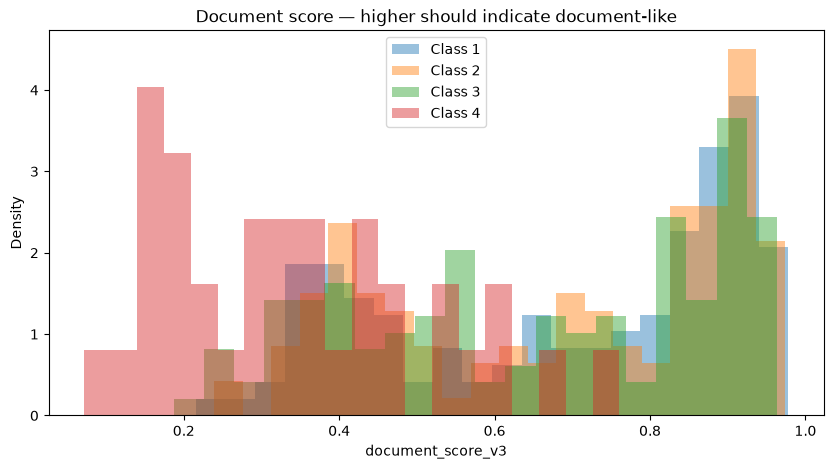

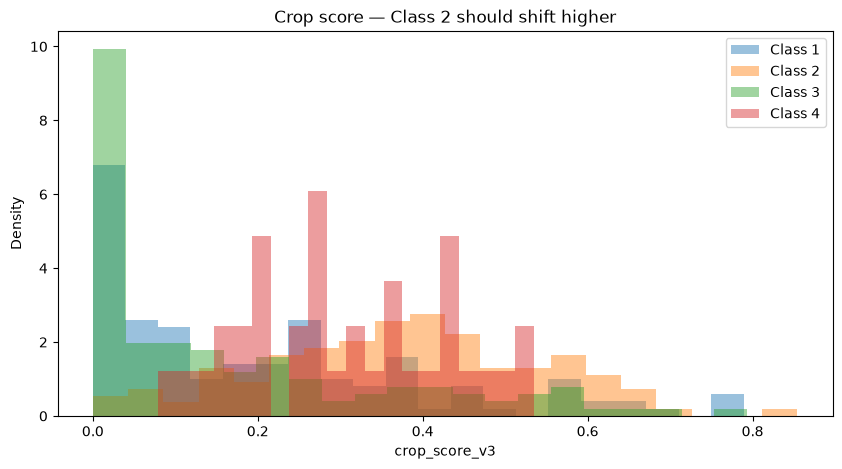

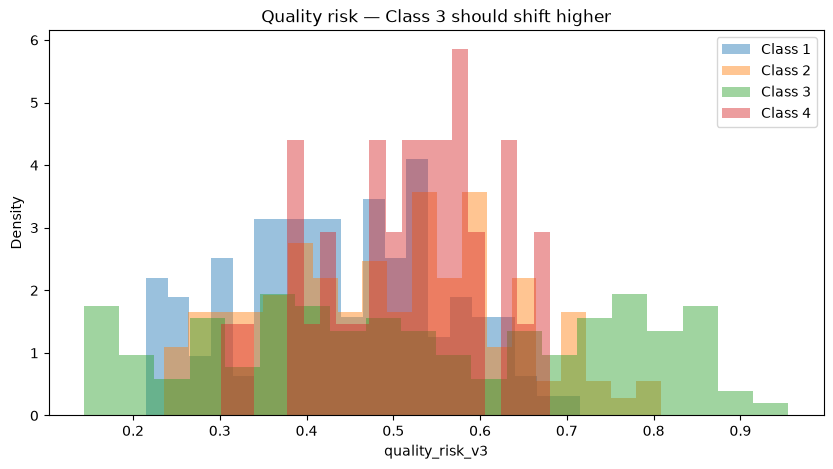

In [11]:
score_specs = [
    (
        "document_score_v3",
        "Document score — higher should indicate document-like",
    ),
    (
        "crop_score_v3",
        "Crop score — Class 2 should shift higher",
    ),
    (
        "quality_risk_v3",
        "Quality risk — Class 3 should shift higher",
    ),
]

for score_name, title in score_specs:
    plt.figure(figsize=(10, 5))

    for class_id in [1, 2, 3, 4]:
        values = features_df.loc[
            features_df["class_id"] == class_id,
            score_name,
        ]

        plt.hist(
            values,
            bins=20,
            alpha=0.45,
            density=True,
            label=f"Class {class_id}",
        )

    plt.xlabel(score_name)
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.show()

## 12. Raw feature separation tables

In [19]:
crop_feature_columns = [
    "crop_cc_touch_ratio",
    "crop_cc_touch_area_ratio",
    "crop_cc_sides_touched",
    "crop_boundary_ink_max",
    "crop_boundary_ink_sides_active",
    "crop_projection_delta_max",
    "crop_projection_ratio_max",
    "edge_touch_count_v3",
]

quality_feature_columns = [
    "laplacian_variance",
    "local_laplacian_p25",
    "tenengrad_mean",
    "quality_fft_local_p25",
    "intensity_dynamic_range",
    "underexposed_ratio",
    "overexposed_ratio",
    "noise_residual_mad",
    "near_binary_ratio",
]

print("Crop features — medians by class")
display(
    features_df
    .groupby("class_id")[crop_feature_columns]
    .median()
    .round(4)
)

print("Quality features — medians by class")
display(
    features_df
    .groupby("class_id")[quality_feature_columns]
    .median()
    .round(4)
)

Crop features — medians by class


,crop_cc_touch_ratio,crop_cc_touch_area_ratio,crop_cc_sides_touched,crop_boundary_ink_max,crop_boundary_ink_sides_active,crop_projection_delta_max,crop_projection_ratio_max,edge_touch_count_v3
class_id,,,,,,,,
1,0.0152,0.0558,3.0,0.0877,2.0,0.0315,2.2562,1.0
2,0.0677,0.2001,3.0,0.1513,2.0,0.0447,2.1189,2.0
3,0.0084,0.0251,2.0,0.0401,1.0,0.0150,1.9343,3.0
4,0.0780,0.1250,3.5,0.1864,3.0,0.0109,1.1621,3.0


Quality features — medians by class


,laplacian_variance,local_laplacian_p25,tenengrad_mean,quality_fft_local_p25,intensity_dynamic_range,underexposed_ratio,overexposed_ratio,noise_residual_mad,near_binary_ratio
class_id,,,,,,,,,
1,458.7076,279.5131,16704.8815,0.1546,136.0,0.0108,0.3782,0.3256,0.5127
2,243.8776,124.4439,12431.5713,0.1048,136.0,0.0104,0.3411,0.2875,0.4778
3,230.2153,139.0433,4026.7609,0.1276,90.0,0.0129,0.0257,0.2073,0.2342
4,155.5909,44.4594,6827.7472,0.0251,189.0,0.0818,0.0078,0.5644,0.0861


## 15. Save the Iteration 3 feature table

In [12]:
features_df.to_csv(
    V3_FEATURE_PATH,
    index=False,
)

print("Saved:", V3_FEATURE_PATH.resolve())
print("Rows:", len(features_df))
print("Columns:", len(features_df.columns))

print("\nUse these raw features in Notebook 3:")
print("- crop_cc_touch_ratio")
print("- crop_cc_touch_area_ratio")
print("- crop_boundary_ink_max")
print("- crop_boundary_ink_sides_active")
print("- crop_projection_delta_max")
print("- local_laplacian_p25")
print("- tenengrad_mean")
print("- quality_fft_local_p25")
print("- intensity_dynamic_range")
print("- underexposed_ratio")
print("- overexposed_ratio")
print("- noise_residual_mad")
print("- near_binary_ratio")

Saved: /Users/aparna/Desktop/Projects/varaha/document_gateway/eval/dataset/cv_features_v3.csv
Rows: 417
Columns: 80

Use these raw features in Notebook 3:
- crop_cc_touch_ratio
- crop_cc_touch_area_ratio
- crop_boundary_ink_max
- crop_boundary_ink_sides_active
- crop_projection_delta_max
- local_laplacian_p25
- tenengrad_mean
- quality_fft_local_p25
- intensity_dynamic_range
- underexposed_ratio
- overexposed_ratio
- noise_residual_mad
- near_binary_ratio
